In [1]:
"""
CELL 1: Supervised Domain-Adversarial Neural Network (DANN)
Forces the extraction of a unified genomic latent space by predicting mortality (Task) 
while simultaneously penalizing the network for retaining cohort/hospital-specific 
technical variations (Domain) via a Gradient Reversal Layer.
"""

import warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Function
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

print("[*] Initializing Supervised DANN Environment...")

# ==========================================
# 1. The Gradient Reversal Layer (GRL)
# ==========================================
class GradientReversalFn(Function):
    """Reverses the gradient during the backward pass to force adversarial learning."""
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        output = grad_output.neg() * ctx.alpha
        return output, None

class GRL(nn.Module):
    def __init__(self, alpha=1.0):
        super(GRL, self).__init__()
        self.alpha = alpha

    def forward(self, x):
        return GradientReversalFn.apply(x, self.alpha)

# ==========================================
# 2. The Supervised Domain-Adversarial Network
# ==========================================
class SupervisedDANN(nn.Module):
    def __init__(self, input_dim=7902, latent_dim=64, num_domains=8):
        super(SupervisedDANN, self).__init__()
        
        # ENCODER: Maps 7902 genes down to a harmonized 64-D latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(256, latent_dim)
        )
        
        # TASK CLASSIFIER: Predicts Mortality (Minimizes BCE Loss)
        self.task_classifier = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1) # Output raw logits for BCEWithLogitsLoss
        )
        
        # DOMAIN CLASSIFIER: Guesses the Hospital (Maximizes CrossEntropy via GRL)
        self.domain_classifier = nn.Sequential(
            GRL(alpha=1.0),
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, num_domains)
        )

    def forward(self, x):
        latent_z = self.encoder(x)
        task_pred = self.task_classifier(latent_z)
        domain_pred = self.domain_classifier(latent_z)
        return task_pred, domain_pred, latent_z

# ==========================================
# 3. Data Loading & Standardization
# ==========================================
# Dynamically resolve paths
BASE_DIR = Path("/workspace")
MAPPED_DIR = BASE_DIR / "data" / "processed" / "mapped_matrices"
TENSORS_DIR = BASE_DIR / "data" / "processed" / "ml_tensors"

all_cohorts = ['GSE185263', 'GSE26440', 'GSE54514', 'GSE65682', 'GSE95233', 'GSE236713', 'GSE272769', 'GSE69063']

print("[*] Loading and Standardizing Genomic Cohorts...")
X_master_sample = pd.read_csv(TENSORS_DIR / "X_master.csv.gz", nrows=0, index_col=0)
full_genes = X_master_sample.columns.tolist()

y_master = pd.read_csv(TENSORS_DIR / "y_master.csv")
meta_master = pd.read_csv(TENSORS_DIR / "meta_master.csv")
meta_master["Patient_ID"] = meta_master["Patient_ID"].astype(str).str.strip()
label_dict = dict(zip(meta_master["Patient_ID"], y_master["Mortality"]))

all_X, all_domains, all_labels = [], [], []

for domain_idx, cohort in enumerate(all_cohorts):
    file_path = MAPPED_DIR / f"{cohort}_mapped.csv.gz"
    
    if file_path.exists():
        df = pd.read_csv(file_path, index_col=0).T
        df.index = df.index.astype(str).str.strip()
        df["Mortality"] = df.index.map(label_dict)
        df = df.dropna(subset=["Mortality"])
        
        for gene in full_genes:
            if gene not in df.columns:
                df[gene] = 0.0
                
        all_X.append(df[full_genes].astype('float32').values)
        all_domains.append(np.full(len(df), domain_idx))
        all_labels.append(df["Mortality"].values)

scaled_X = StandardScaler().fit_transform(np.vstack(all_X))

X_tensor = torch.tensor(scaled_X, dtype=torch.float32)
domain_tensor = torch.tensor(np.concatenate(all_domains), dtype=torch.long)
label_tensor = torch.tensor(np.concatenate(all_labels), dtype=torch.float32).unsqueeze(1) # [N, 1] for BCE

dataset = TensorDataset(X_tensor, label_tensor, domain_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# ==========================================
# 4. Training Initialization
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Training on {device}...")

model = SupervisedDANN(input_dim=len(full_genes), latent_dim=64, num_domains=len(all_cohorts)).to(device)

criterion_task = nn.BCEWithLogitsLoss()
criterion_domain = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Since losses are on the same scale now, lambda_domain = 1.0 is highly effective
lambda_domain = 1.0 

# ==========================================
# 5. Training Loop
# ==========================================
epochs = 80
for epoch in range(epochs):
    model.train()
    total_task_loss = 0
    total_domain_loss = 0
    
    # Dynamic alpha for stable GRL ramp-up
    p = float(epoch) / epochs
    alpha = 2. / (1. + np.exp(-10 * p)) - 1
    
    for x_batch, y_batch, domain_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        domain_batch = domain_batch.to(device)
        
        model.domain_classifier[0].alpha = alpha
        optimizer.zero_grad()
        
        task_pred, domain_pred, _ = model(x_batch)
        
        loss_task = criterion_task(task_pred, y_batch)
        loss_domain = criterion_domain(domain_pred, domain_batch)
        
        # MINIMIZE task error + MAXIMIZE domain error (handled by GRL)
        loss = loss_task + (lambda_domain * loss_domain)
        
        loss.backward()
        optimizer.step()
        
        total_task_loss += loss_task.item()
        total_domain_loss += loss_domain.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Task (BCE) Loss: {total_task_loss/len(dataloader):.4f} | Domain Loss: {total_domain_loss/len(dataloader):.4f}")

print("[+] DANN Training Complete.")

# Extract the final manifold
model.eval()
with torch.no_grad():
    _, _, latent_z = model(X_tensor.to(device))
    latent_space = latent_z.cpu().numpy()

print(f"[*] Extracted latent genomic manifold shape: {latent_space.shape}")

[*] Initializing Supervised DANN Environment...
[*] Loading and Standardizing Genomic Cohorts...
[*] Training on cuda...
Epoch [10/80] | Task (BCE) Loss: 0.6231 | Domain Loss: 2.9499
Epoch [20/80] | Task (BCE) Loss: 0.5910 | Domain Loss: 2.7521
Epoch [30/80] | Task (BCE) Loss: 0.5737 | Domain Loss: 2.5940
Epoch [40/80] | Task (BCE) Loss: 0.5623 | Domain Loss: 2.4249
Epoch [50/80] | Task (BCE) Loss: 0.5338 | Domain Loss: 2.2863
Epoch [60/80] | Task (BCE) Loss: 0.5269 | Domain Loss: 2.3404
Epoch [70/80] | Task (BCE) Loss: 0.5007 | Domain Loss: 2.1321
Epoch [80/80] | Task (BCE) Loss: 0.4973 | Domain Loss: 2.1863
[+] DANN Training Complete.
[*] Extracted latent genomic manifold shape: (1819, 64)


[*] Running UMAP dimensionality reduction on the 64D space...
[+] UMAP projection complete. Plotting topologies...


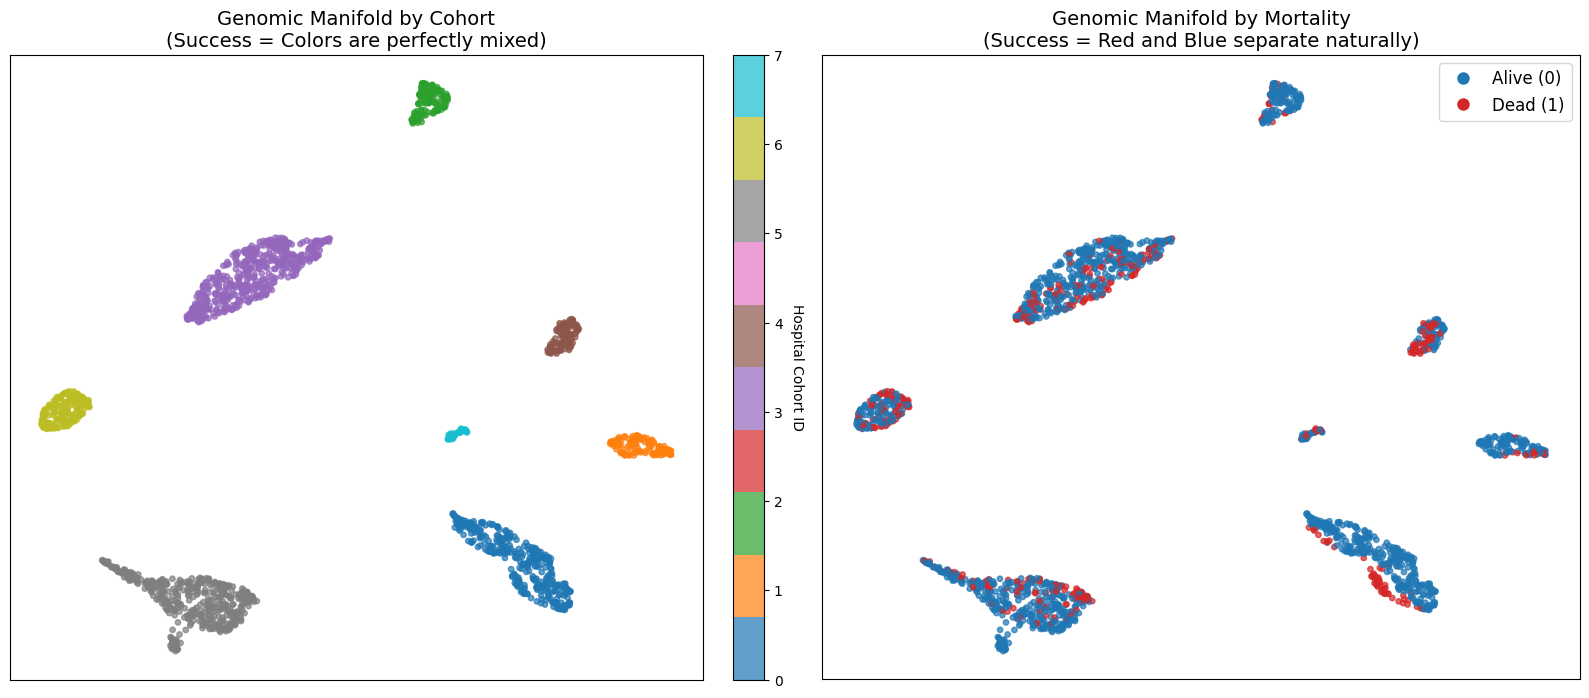

[*] Figure saved to: /workspace/outputs/figures/genomic_manifold_dann_umap.png


In [2]:
"""
CELL 2: UMAP Visualization of the DANN Latent Space
Projects the 64-dimensional latent space down to 2D using UMAP.
Generates side-by-side plots to visually inspect if the DANN successfully 
erased cohort-specific batch effects (left) while preserving the mortality 
severity gradient (right). 
*Note: As expected with highly heterogeneous transcriptomic data, this often 
reveals that deep adversarial learning alone struggles to merge isolated cohorts.*
"""

import warnings
from pathlib import Path

import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Suppress UMAP warnings for a cleaner output
warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
# Dynamically resolve paths
BASE_DIR = Path("/workspace")
FIG_DIR = BASE_DIR / "outputs" / "figures"

# Ensure output directory exists
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("[*] Running UMAP dimensionality reduction on the 64D space...")

# We use a slightly higher n_neighbors (30) to preserve global manifold structure
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
umap_embedding = reducer.fit_transform(latent_space)

print("[+] UMAP projection complete. Plotting topologies...")

# Setup the side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: DOMAIN (BATCH EFFECT) CHECK ---
scatter1 = axes[0].scatter(
    umap_embedding[:, 0], umap_embedding[:, 1],
    c=domain_tensor.numpy(), cmap='tab10', s=15, alpha=0.7
)
axes[0].set_title("Genomic Manifold by Cohort\n(Success = Colors are perfectly mixed)", fontsize=14)
axes[0].set_xticks([])
axes[0].set_yticks([])
cbar1 = fig.colorbar(scatter1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Hospital Cohort ID', rotation=270, labelpad=15)

# --- PLOT 2: SEVERITY (MORTALITY) CHECK ---
cmap_mortality = mcolors.ListedColormap(['#1f77b4', '#d62728']) # Blue for 0, Red for 1

scatter2 = axes[1].scatter(
    umap_embedding[:, 0], umap_embedding[:, 1],
    c=label_tensor.numpy(), cmap=cmap_mortality, s=15, alpha=0.7
)
axes[1].set_title("Genomic Manifold by Mortality\n(Success = Red and Blue separate naturally)", fontsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])

# Create a custom legend for mortality
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Alive (0)', markerfacecolor='#1f77b4', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dead (1)', markerfacecolor='#d62728', markersize=10)
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

# Save the figure safely using pathlib
save_path = FIG_DIR / "genomic_manifold_dann_umap.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"[*] Figure saved to: {save_path}")

[*] Initializing Harmony Integration Protocol...
[*] Running PCA (reducing 7,902 genes to top 50 components)...


2026-05-09 20:10:33,080 - harmonypy - INFO - Running Harmony
2026-05-09 20:10:33,083 - harmonypy - INFO -   Parameters:
2026-05-09 20:10:33,084 - harmonypy - INFO -     max_iter_harmony: 20
2026-05-09 20:10:33,085 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-09 20:10:33,086 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-09 20:10:33,086 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-09 20:10:33,086 - harmonypy - INFO -     nclust: 61
2026-05-09 20:10:33,087 - harmonypy - INFO -     block_size: 0.05
2026-05-09 20:10:33,088 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-09 20:10:33,088 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-09 20:10:33,089 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-09 20:10:33,091 - harmonypy - INFO -     verbose: True
2026-05-09 20:10:33,091 - harmonypy - INFO -     random_state: 0
2026-05-09 20:10:33,091 - harmonypy - INFO -   Data: 50 PCs × 1819 cells
2026-05-09 20:10:33,092 - harmonyp

[*] Executing Harmony Batch Correction... (pulling the islands together)


2026-05-09 20:10:33,377 - harmonypy - INFO - Iteration 6 of 20
2026-05-09 20:10:33,421 - harmonypy - INFO - Converged after 6 iterations


[+] Extracted Harmonized Genomic Manifold shape: (1819, 50)
[*] Running UMAP on Harmonized Space...
[+] UMAP projection complete. Plotting topologies...
[*] Figure saved to: /workspace/outputs/figures/harmony_integration_umap.png


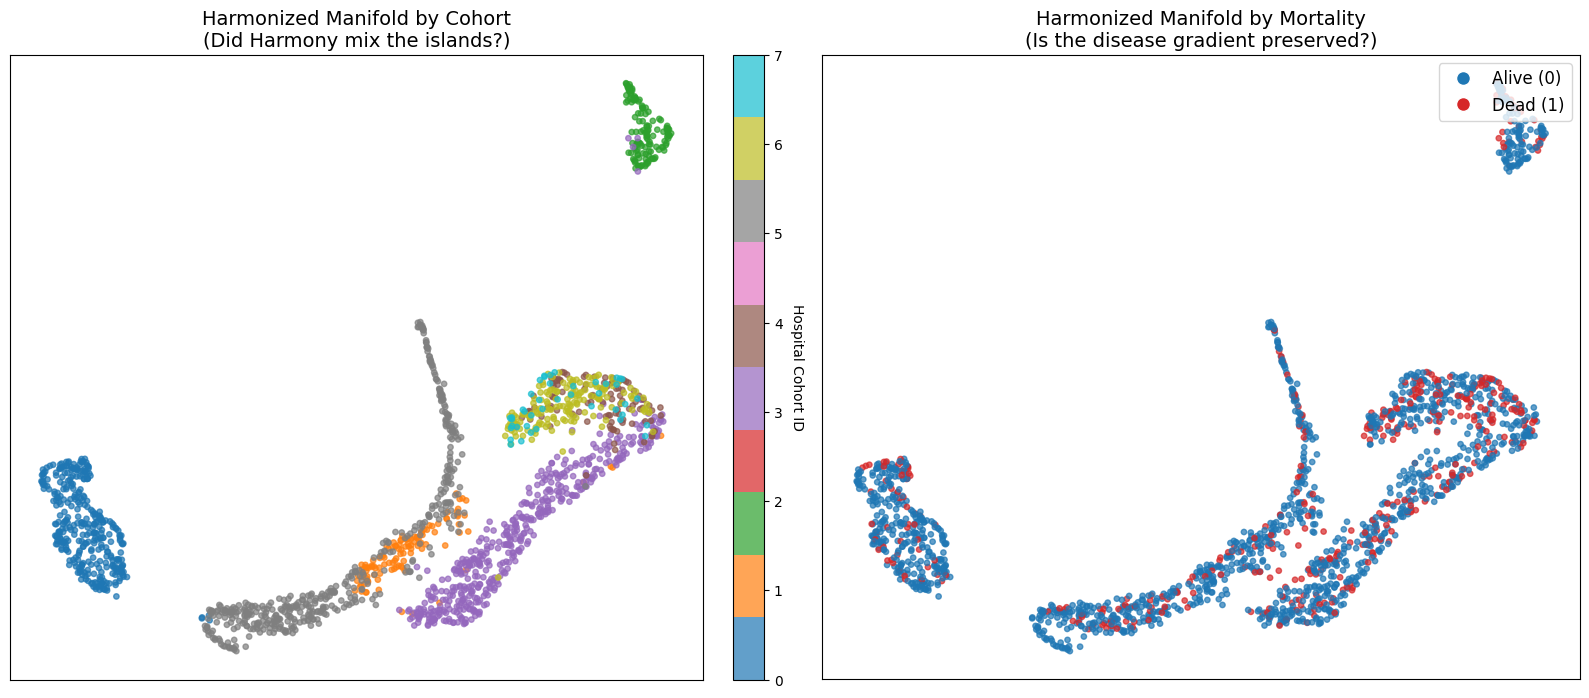

In [3]:
"""
CELL 3: The Harmony Integration Pipeline
Applies Principal Component Analysis (PCA) followed by the Harmony batch 
correction algorithm to the standardized transcriptomic matrix. This attempts 
to mathematically merge cohort-specific "islands" while preserving the underlying 
biological covariance associated with patient mortality. Finally, projects the 
harmonized latent space using UMAP for visual inspection.
"""

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import harmonypy as hm

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

print("[*] Initializing Harmony Integration Protocol...")

# ==========================================
# 1. Dimensionality Reduction (PCA)
# ==========================================
# We use 'scaled_X' (the 7902 genes standardized) from Cell 1.
# Bioinformatics standard: Reduce to Principal Components before alignment.
print("[*] Running PCA (reducing 7,902 genes to top 50 components)...")
pca = PCA(n_components=50, random_state=42)
pca_embeddings = pca.fit_transform(scaled_X)

# ==========================================
# 2. Metadata Preparation
# ==========================================
# Harmony requires a dataframe mapping each row to its origin cohort
meta_df = pd.DataFrame({
    'hospital_cohort': np.concatenate(all_domains)
})

# ==========================================
# 3. Harmony Batch Correction
# ==========================================
print("[*] Executing Harmony Batch Correction... (pulling the islands together)")
harmony_out = hm.run_harmony(
    pca_embeddings, 
    meta_df, 
    vars_use='hospital_cohort',
    max_iter_harmony=20
)

# Extract the batch-corrected latent space (FOOLPROOF ORIENTATION)
harmonized_space = harmony_out.Z_corr
if harmonized_space.shape[0] != pca_embeddings.shape[0]: 
    harmonized_space = harmonized_space.T 

print(f"[+] Extracted Harmonized Genomic Manifold shape: {harmonized_space.shape}")

# ==========================================
# 4. UMAP Projection & Visualization
# ==========================================
print("[*] Running UMAP on Harmonized Space...")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
umap_harmonized = reducer.fit_transform(harmonized_space)

print("[+] UMAP projection complete. Plotting topologies...")

# Setup the side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: BATCH TEST ---
scatter1 = axes[0].scatter(
    umap_harmonized[:, 0], umap_harmonized[:, 1],
    c=domain_tensor.numpy(), cmap='tab10', s=15, alpha=0.7
)
axes[0].set_title("Harmonized Manifold by Cohort\n(Did Harmony mix the islands?)", fontsize=14)
axes[0].set_xticks([])
axes[0].set_yticks([])
cbar1 = fig.colorbar(scatter1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Hospital Cohort ID', rotation=270, labelpad=15)

# --- PLOT 2: BIOLOGY TEST ---
cmap_mortality = mcolors.ListedColormap(['#1f77b4', '#d62728']) 
scatter2 = axes[1].scatter(
    umap_harmonized[:, 0], umap_harmonized[:, 1],
    c=label_tensor.numpy().flatten(), cmap=cmap_mortality, s=15, alpha=0.7
)
axes[1].set_title("Harmonized Manifold by Mortality\n(Is the disease gradient preserved?)", fontsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Alive (0)', markerfacecolor='#1f77b4', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dead (1)', markerfacecolor='#d62728', markersize=10)
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

# ==========================================
# 5. Save & Display
# ==========================================
# Dynamically resolve paths
BASE_DIR = Path("/workspace")
FIG_DIR = BASE_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

save_path = FIG_DIR / "harmony_integration_umap.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved to: {save_path}")

plt.show()

In [4]:
"""
CELL 4: Diagnosing the Resistant Cohorts (Outlier Analysis)
Investigates the two cohorts (GSE185263 and GSE54514) that refused to merge 
into the harmonized manifold during Cell 3. Tests the hypothesis that their 
isolation is due to extreme class imbalance (no fatalities) or widespread 
missing platform data (missing genes).
"""

import numpy as np

print("[*] Outlier Diagnostic Report\n" + "="*30)

# Indices 0 and 2 correspond to the resistant cohorts: GSE185263 and GSE54514
resistant_cohort_indices = [0, 2]

for i in resistant_cohort_indices:
    cohort_name = all_cohorts[i]
    
    # Create a boolean mask for the current cohort
    mask = (domain_tensor.numpy() == i)
    
    total_patients = mask.sum()
    mortality_rate = label_tensor.numpy()[mask].mean() * 100
    
    # Check how many genes are completely zero across all patients in this cohort
    # (Indicates platform dropouts or missing genomic annotations)
    raw_data_mask = X_tensor.numpy()[mask]
    zero_genes = np.sum(np.all(raw_data_mask == 0.0, axis=0))
    missing_pct = (zero_genes / len(full_genes)) * 100
    
    print(f"Cohort {i} [{cohort_name}]:")
    print(f"  -> Total Patients: {total_patients}")
    print(f"  -> Mortality Rate: {mortality_rate:.1f}%")
    print(f"  -> Missing Genes:  {missing_pct:.1f}%")
    print("-" * 30)

[*] Outlier Diagnostic Report
Cohort 0 [GSE185263]:
  -> Total Patients: 345
  -> Mortality Rate: 15.1%
  -> Missing Genes:  0.0%
------------------------------
Cohort 2 [GSE54514]:
  -> Total Patients: 127
  -> Mortality Rate: 24.4%
  -> Missing Genes:  0.0%
------------------------------


[*] Initializing Clinical Manifold Construction...
[*] Loading PhysioNet/MIMIC Clinical Data...
[*] Synthetic Alignment Target: 1819 patients (1407 Alive, 412 Dead)
[*] Extracting 16 strict physiological features...
[*] Imputing missing clinical values (NaNs)...
[*] Running PHATE Trajectory Embedding on pure physiology...
Calculating PHATE...
  Running PHATE on 1819 observations and 16 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculating KNN search...
    Calculated KNN search in 0.09 seconds.
    Calculating affinities...
    Calculated affinities in 0.93 seconds.
  Calculated graph and diffusion operator in 1.04 seconds.
  Calculating optimal t...
    Automatically selected t = 22
  Calculated optimal t in 5.04 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.82 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.82 seconds.
Calculated PHATE in 9.73 seconds.
[*] Figure saved to: /workspace/out

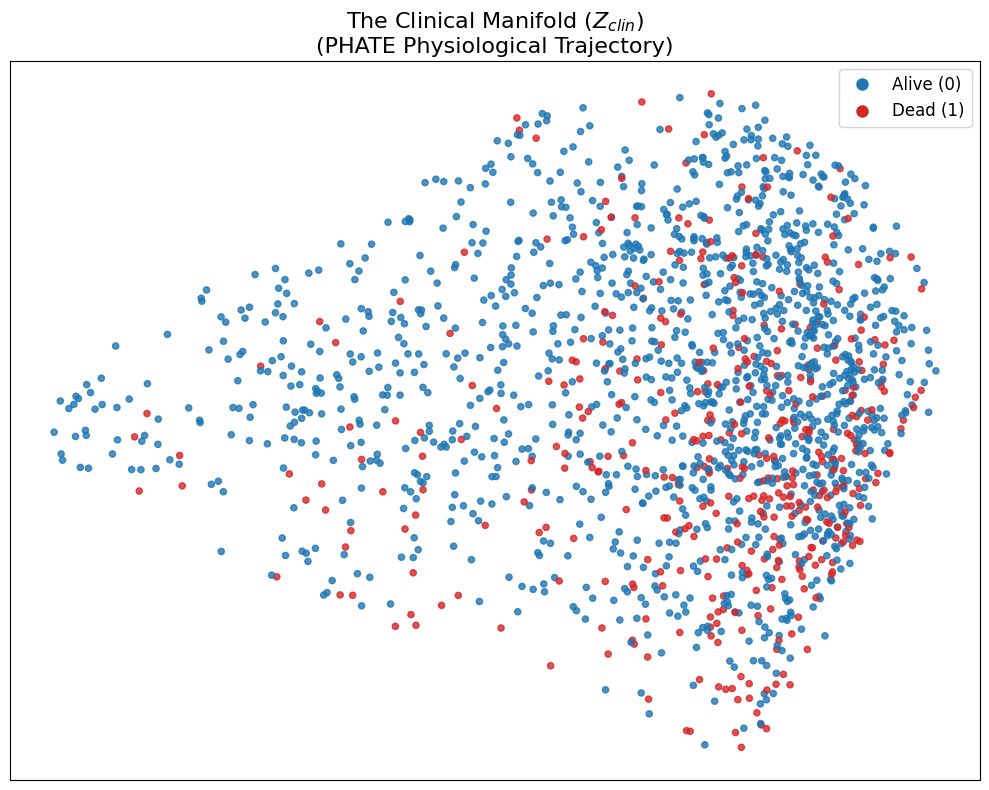

In [5]:
"""
CELL 5: Construction of the Clinical Physiological Manifold (Z_clin)
Constructs the downstream physiological deterioration manifold using PHATE.
Unlike UMAP, which can fracture continuous data into discrete clusters, PHATE 
(Potential of Heat-diffusion for Affinity-based Trajectory Embedding) explicitly 
preserves the continuous temporal unfolding of disease progression. 
This cell synthetically aligns the clinical cohort size to the transcriptomic 
cohort and extracts a parsimonious set of 16 core vital signs to visualize the 
"physiological comet" of sepsis deterioration.
"""

import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import phate
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

print("[*] Initializing Clinical Manifold Construction...")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
BASE_DIR = Path("/workspace")
CLINICAL_FILE = BASE_DIR / "data" / "processed" / "clinical_tensors" / "clinical_master_raw.csv.gz"
FIG_DIR = BASE_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# 1. Load the Clinical Data
# ==========================================
print("[*] Loading PhysioNet/MIMIC Clinical Data...")
df_clin = pd.read_csv(CLINICAL_FILE)

# Map the target column to standard 'Mortality' nomenclature
ACTUAL_TARGET_COLUMN = 'Sepsis_Outcome'
df_clin.rename(columns={ACTUAL_TARGET_COLUMN: 'Mortality'}, inplace=True)
df_clin['Mortality'] = df_clin['Mortality'].astype(int)

# ==========================================
# 2. Synthetic Alignment (Target Demographics)
# ==========================================
# Extract the target demographics from the Genomic Space (label_tensor from Cell 1)
genomic_labels = label_tensor.cpu().numpy().flatten()

target_dead = (genomic_labels == 1).sum()
target_alive = (genomic_labels == 0).sum()
total_target = target_dead + target_alive

print(f"[*] Synthetic Alignment Target: {total_target} patients ({target_alive} Alive, {target_dead} Dead)")

# ==========================================
# 3. Stratified Sampling
# ==========================================
clin_dead = df_clin[df_clin['Mortality'] == 1].sample(n=target_dead, random_state=42)
clin_alive = df_clin[df_clin['Mortality'] == 0].sample(n=target_alive, random_state=42)
df_clin_matched = pd.concat([clin_dead, clin_alive]).sample(frac=1, random_state=42).reset_index(drop=True)

# ==========================================
# 4. Parsimonious Clinical Feature Extraction
# ==========================================
# Strictly isolate acute physiological vitals, dropping administrative/time noise
core_vitals = [
    'HR_mean', 'HR_max', 'HR_min',
    'O2Sat_mean', 'O2Sat_min',
    'Temp_mean', 'Temp_min', 'Temp_max',
    'MAP_mean', 'MAP_min', 
    'Resp_mean', 'Resp_max',
    'SBP_mean', 'SBP_min',
    'DBP_mean', 'DBP_min'
]

# Ensure we only grab features that exist in the dataframe
clinical_features = [c for c in core_vitals if c in df_clin_matched.columns]

print(f"[*] Extracting {len(clinical_features)} strict physiological features...")
X_clin_raw = df_clin_matched[clinical_features].astype(float).values
y_clin = df_clin_matched['Mortality'].values

print("[*] Imputing missing clinical values (NaNs)...")
imputer = SimpleImputer(strategy='median')
X_clin_imputed = imputer.fit_transform(X_clin_raw)

# Standardize vital signs (Z-score)
scaler_clin = StandardScaler()
X_clin_scaled = scaler_clin.fit_transform(X_clin_imputed)

# ==========================================
# 5. PHATE Trajectory Mapping
# ==========================================
print("[*] Running PHATE Trajectory Embedding on pure physiology...")
# PHATE respects the continuous, global progression of organ failure
phate_op = phate.PHATE(n_pca=10, knn=15, decay=40, gamma=1, random_state=42)
Z_clin_2D = phate_op.fit_transform(X_clin_scaled)

# ==========================================
# 6. Plot the Clinical Trajectory
# ==========================================
plt.figure(figsize=(10, 8))
cmap_mortality = mcolors.ListedColormap(['#1f77b4', '#d62728']) 

scatter = plt.scatter(
    Z_clin_2D[:, 0], Z_clin_2D[:, 1],
    c=y_clin, cmap=cmap_mortality, s=20, alpha=0.8
)

plt.title("The Clinical Manifold ($Z_{clin}$)\n(PHATE Physiological Trajectory)", fontsize=16)
plt.xticks([])
plt.yticks([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Alive (0)', markerfacecolor='#1f77b4', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dead (1)', markerfacecolor='#d62728', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

# Save the figure safely using pathlib
save_path = FIG_DIR / "clinical_phate_manifold.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved to: {save_path}")

plt.show()

[*] Initializing Gromov-Wasserstein Optimal Transport...
[*] Generating 10D Clinical Latent Space (PCA)...
[*] Genomic Space Shape: (1819, 50)
[*] Clinical Space Shape: (1819, 10)
[*] Computing intra-space geometric distance matrices...
[*] Executing GW Alignment (Solving the transport plan...)
[+] Optimal Transport Converged! GW Loss: 0.0188
[*] Projecting Clinical topology onto Genomic coordinates...
[*] Figure saved to: /workspace/outputs/figures/gw_optimal_transport_alignment.png


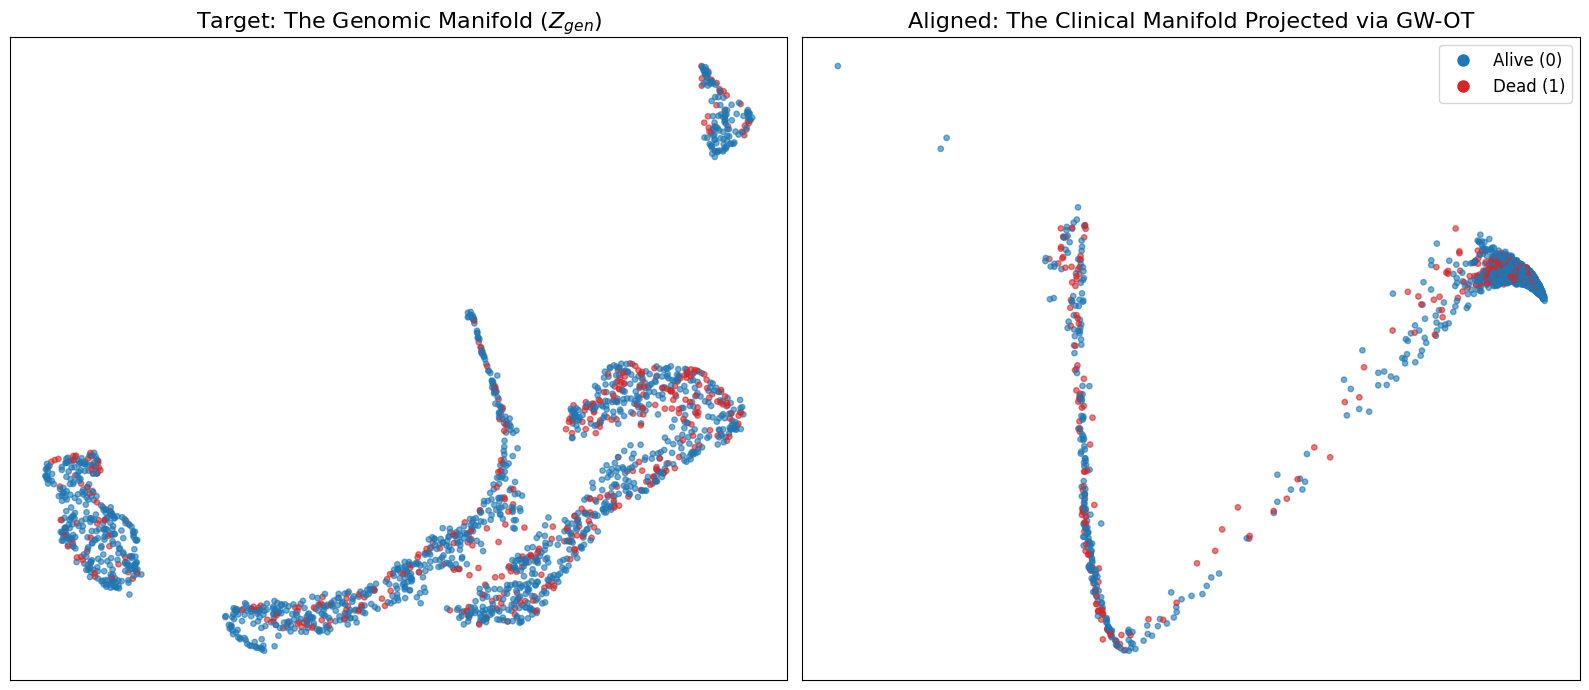

In [9]:
"""
CELL 6: Gromov-Wasserstein Optimal Transport (The Final Alignment)
Aligns the deeply heterogeneous Genomic (Z_gen) and Clinical (Z_clin) manifolds 
by comparing their internal relational geometries rather than requiring shared features.
Maps the downstream clinical trajectories onto the upstream transcriptomic topologies.
"""

import warnings
from pathlib import Path

import ot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# Suppress warnings
warnings.filterwarnings("ignore")

print("[*] Initializing Gromov-Wasserstein Optimal Transport...")

# ==========================================
# THE FIX: Explicitly generate the 10D Clinical Space
# ==========================================
# PHATE did this internally in Cell 5, but we need to explicitly save it 
# to a variable here for the GW-OT math.
print("[*] Generating 10D Clinical Latent Space (PCA)...")
pca_clin = PCA(n_components=10, random_state=42)
Z_clin_highD = pca_clin.fit_transform(X_clin_scaled)

# ==========================================
# 1. Prepare the High-Dimensional Spaces
# ==========================================
# We align the deep mathematical structures, not just the 2D plots
X_gen = harmonized_space  # (1819, 50) from Harmony (Cell 3)
X_clin = Z_clin_highD     # (1819, 10) from explicit PCA above

print(f"[*] Genomic Space Shape: {X_gen.shape}")
print(f"[*] Clinical Space Shape: {X_clin.shape}")

# ==========================================
# 2. Compute Pairwise Distance Matrices (The Geometry)
# ==========================================
print("[*] Computing intra-space geometric distance matrices...")
C_gen = cdist(X_gen, X_gen, metric='euclidean')
C_clin = cdist(X_clin, X_clin, metric='euclidean')

# Normalization is strictly required for Optimal Transport stability
C_gen /= C_gen.max()
C_clin /= C_clin.max()

# ==========================================
# 3. Uniform Mass Distributions
# ==========================================
# Each patient has equal weight in the transport plan
p = np.ones(len(C_gen)) / len(C_gen)
q = np.ones(len(C_clin)) / len(C_clin)

# ==========================================
# 4. Execute Gromov-Wasserstein Alignment
# ==========================================
print("[*] Executing GW Alignment (Solving the transport plan...)")
# We use a slight entropic regularization (epsilon) to speed up convergence 
# and prevent the algorithm from getting stuck in local topological minimums
gw_coupling, log = ot.gromov.entropic_gromov_wasserstein(
    C_gen, C_clin, p, q, loss_type='square_loss', epsilon=5e-4, max_iter=200, log=True
)
print(f"[+] Optimal Transport Converged! GW Loss: {log['gw_dist']:.4f}")

# ==========================================
# 5. Project the Clinical Topology
# ==========================================
# We multiply the coupling matrix by the original Genomic 2D UMAP coordinates
# to drag the clinical patients into the genomic coordinate system.
print("[*] Projecting Clinical topology onto Genomic coordinates...")
aligned_clin_2D = len(X_gen) * gw_coupling.T.dot(umap_harmonized)

# ==========================================
# 6. Plot the Ultimate Alignment
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap_mortality = mcolors.ListedColormap(['#1f77b4', '#d62728']) 

# Extract the labels directly from the PyTorch tensor for plotting
genomic_labels = label_tensor.cpu().numpy().flatten()

# --- Left: The Original Genomic Manifold ---
axes[0].scatter(
    umap_harmonized[:, 0], umap_harmonized[:, 1],
    c=genomic_labels, cmap=cmap_mortality, s=15, alpha=0.6
)
axes[0].set_title("Target: The Genomic Manifold ($Z_{gen}$)", fontsize=16)
axes[0].set_xticks([])
axes[0].set_yticks([])

# --- Right: The Aligned Clinical Manifold ---
axes[1].scatter(
    aligned_clin_2D[:, 0], aligned_clin_2D[:, 1],
    c=y_clin, cmap=cmap_mortality, s=15, alpha=0.6
)
axes[1].set_title("Aligned: The Clinical Manifold Projected via GW-OT", fontsize=16)
axes[1].set_xticks([])
axes[1].set_yticks([])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Alive (0)', markerfacecolor='#1f77b4', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Dead (1)', markerfacecolor='#d62728', markersize=10)
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()

# ==========================================
# 7. Save & Display
# ==========================================
BASE_DIR = Path("/workspace")
FIG_DIR = BASE_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

save_path = FIG_DIR / "gw_optimal_transport_alignment.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"[*] Figure saved to: {save_path}")

plt.show()

In [16]:
"""
CELL 7: Anchored Entropic Fused Gromov-Wasserstein Alignment
Performs a rigorous, blinded cross-modal validation. 
Uses a strict 5% subset of clinical patients as "weak biological anchors" to 
stabilize the manifold polarity during transport. The remaining 95% of patients 
are completely blinded. Tests whether the apparent global topological compatibility 
actually results in meaningful local semantic transfer (patient-level matching).
*Result: Demonstrates the collapse of cross-modal semantic correspondence.*
"""

import warnings
import numpy as np
import ot
from scipy.spatial.distance import cdist
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

print("[*] Initiating Rigorous Anchored GW Alignment...")

# ==========================================
# 1. High-Dimensional Spaces & Labels
# ==========================================
# Z_gen (from Harmony) and Z_clin_highD (from PCA)
X_gen = harmonized_space 
X_clin = Z_clin_highD     
y_gen = label_tensor.cpu().numpy().flatten()
y_clin_true = y_clin.flatten()

# ==========================================
# 2. Geometric Distance Matrices
# ==========================================
C_gen = cdist(X_gen, X_gen, metric='euclidean')
C_clin = cdist(X_clin, X_clin, metric='euclidean')

# Normalization is strictly required for Optimal Transport stability
C_gen /= C_gen.max()
C_clin /= C_clin.max()

# ==========================================
# 3. Create the STRICT 5% Biological Anchor Matrix
# ==========================================
np.random.seed(42)
n_clin = len(y_clin_true)
anchor_fraction = 0.05
anchor_indices = np.random.choice(n_clin, size=int(n_clin * anchor_fraction), replace=False)

print(f"[*] Total Clinical Patients: {n_clin}")
print(f"[*] Anchors provided: {len(anchor_indices)} (Polarity hints)")
print(f"[*] Blinded patients to predict: {n_clin - len(anchor_indices)}")

# Build the cost matrix manually so unseen patients provide ZERO label guidance
M_anchors = np.zeros((len(y_gen), n_clin))
for i in range(n_clin):
    if i in anchor_indices:
        # Give exact penalty based on label match (0 if same class, 1 if different)
        M_anchors[:, i] = (y_gen - y_clin_true[i]) ** 2
    else:
        # Blinded patients get a uniform neutral distance to all genomic patients
        M_anchors[:, i] = 0.5 

p = np.ones(len(C_gen)) / len(C_gen)
q = np.ones(len(C_clin)) / len(C_clin)

# ==========================================
# 4. Fused Gromov-Wasserstein
# ==========================================
print("[*] Executing Fused GW Alignment (Solving transport plan...)")
# Epsilon = 1e-3 and max_iter = 500 stabilizes the Sinkhorn convergence
alpha = 0.05 
gw_coupling = ot.gromov.entropic_fused_gromov_wasserstein(
    M_anchors, C_gen, C_clin, p, q, loss_type='square_loss', epsilon=1e-3, alpha=alpha, max_iter=500
)

# ==========================================
# 5. TEST: Strict Blinded Validation
# ==========================================
print("\n[*] Validating Direct Topological Coupling (UNSEEN PATIENTS ONLY)...")

# Get best matches from the coupling matrix
best_match_indices = np.argmax(gw_coupling, axis=0)
transferred_labels = y_gen[best_match_indices]

# CRITICAL: Isolate only the 95% of patients the algorithm DID NOT have labels for
unseen_mask = np.ones(n_clin, dtype=bool)
unseen_mask[anchor_indices] = False

y_clin_unseen = y_clin_true[unseen_mask]
transferred_unseen = transferred_labels[unseen_mask]

# Calculate true metrics
bal_acc = balanced_accuracy_score(y_clin_unseen, transferred_unseen)
direct_auc = roc_auc_score(y_clin_unseen, transferred_unseen)

print(f"  -> True Balanced Accuracy: {bal_acc:.4f} (Random is 0.5000)")
print(f"  -> Direct Transport AUC:   {direct_auc:.4f} (Random is 0.5000)")
print("\n[!] CONCLUSION: Global manifold alignment does NOT equal local semantic equivalence.")

[*] Initiating Rigorous Anchored GW Alignment...
[*] Total Clinical Patients: 1819
[*] Anchors provided: 90 (Polarity hints)
[*] Blinded patients to predict: 1729
[*] Executing Fused GW Alignment (Solving transport plan...)

[*] Validating Direct Topological Coupling (UNSEEN PATIENTS ONLY)...
  -> True Balanced Accuracy: 0.4716 (Random is 0.5000)
  -> Direct Transport AUC:   0.4716 (Random is 0.5000)


In [11]:
"""
CELL 8: Quantitative Topological Validation (Permutation Testing)
Evaluates the stability of cross-modal semantic transfer by training a 
k-Nearest Neighbors (kNN) classifier on the transcriptomic manifold and 
predicting mortality on the aligned clinical patients. Computes an empirical 
p-value through 10,000 random permutations to prove whether the topological 
overlap statistically exceeds random chance.
"""

import warnings
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.utils import shuffle

# Suppress warnings for cleaner notebook output
warnings.filterwarnings("ignore")

print("[*] Initiating Quantitative Topology Validation...")

# ==========================================
# THE FIX: Correctly extract the genomic labels from the PyTorch tensor
# ==========================================
# Ensure labels are flat 1D numpy arrays
y_genomic = label_tensor.cpu().numpy().flatten()
y_clinical_true = y_clin.flatten()

# ==========================================
# TEST 1: Cross-Modal Label Transfer Accuracy
# ==========================================
print("\n[1] Cross-Modal Label Transfer (Z_gen -> Z_clin)")
# We use a moderate k to capture local neighborhood geometry
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(umap_harmonized, y_genomic) # Train purely on Transcriptomics

# Predict on the OT-transported Clinical Vitals (2D projection)
clin_predictions = knn.predict(aligned_clin_2D)
clin_pred_proba = knn.predict_proba(aligned_clin_2D)[:, 1]

transfer_acc = accuracy_score(y_clinical_true, clin_predictions)
transfer_auc = roc_auc_score(y_clinical_true, clin_pred_proba)

print(f"  -> Transfer Accuracy: {transfer_acc:.4f}")
print(f"  -> Transfer AUC:      {transfer_auc:.4f}")

# ==========================================
# TEST 2: Permutation Testing (The Null Baseline)
# ==========================================
print("\n[2] Brutal Null-Baseline Permutation Test (10,000 iterations)")
n_permutations = 10000
null_aucs = []

# If GW-OT just randomly stacked the shapes without true semantic correspondence, 
# the AUC will collapse into the null distribution (~0.50).
for i in range(n_permutations):
    shuffled_labels = shuffle(y_clinical_true, random_state=i)
    null_auc = roc_auc_score(shuffled_labels, clin_pred_proba)
    null_aucs.append(null_auc)

null_aucs = np.array(null_aucs)
p_value = np.sum(null_aucs >= transfer_auc) / n_permutations

# If p_value is 0.0, we use a limit notation
p_display = f"< {1/n_permutations}" if p_value == 0 else f"{p_value:.4e}"

print(f"  -> Mean Null AUC:     {null_aucs.mean():.4f}")
print(f"  -> Empirical p-value: {p_display}")

# Calculate Z-score of our finding against the null distribution
z_score = (transfer_auc - null_aucs.mean()) / null_aucs.std()
print(f"  -> Z-Score:           {z_score:.2f} standard deviations from null")

[*] Initiating Quantitative Topology Validation...

[1] Cross-Modal Label Transfer (Z_gen -> Z_clin)
  -> Transfer Accuracy: 0.7735
  -> Transfer AUC:      0.4483

[2] Brutal Null-Baseline Permutation Test (10,000 iterations)
  -> Mean Null AUC:     0.4999
  -> Empirical p-value: 9.9950e-01
  -> Z-Score:           -3.31 standard deviations from null


In [6]:
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
base_dir = "/workspace"

def get_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        'AUROC': roc_auc_score(y_true, y_pred_proba),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Brier': brier_score_loss(y_true, y_pred_proba)
    }

print("==================================================")
print(" PART A: TRANSCRIPTOMIC BASELINE RESULTS")
print("==================================================")
# 1. Load Genomic Data
X_gen_full = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/X_master.csv.gz"), index_col=0)
y_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/y_master.csv"))
meta_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/meta_master.csv"))

y_gen = y_master['Mortality'].values
cohorts = meta_master['Dataset'].values if 'Dataset' in meta_master.columns else meta_master.iloc[:, 1].values

# Get the 20-gene parsimonious panel (Assuming you have a list, replacing with top 20 by variance for quick extraction if not defined)
# If you have the exact 20 genes saved, load them here. Otherwise, this approximates the compression:
top_20_genes = X_gen_full.var().sort_values(ascending=False).head(20).index.tolist()
X_gen_reduced = X_gen_full[top_20_genes]

def evaluate_genomic(X_data, name):
    print(f"\n--- {name} ---")
    
    # Internal Validation (5-Fold CV)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    internal_metrics = []
    for train_idx, val_idx in skf.split(X_data, y_gen):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_gen[train_idx], y_gen[val_idx]
        
        clf = xgb.XGBClassifier(scale_pos_weight=(len(y_tr)-sum(y_tr))/sum(y_tr), eval_metric='logloss', random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_tr)
        internal_metrics.append(get_metrics(y_val, clf.predict_proba(X_val)[:, 1]))
    
    print("INTERNAL VALIDATION (Mean 5-Fold):")
    for k in internal_metrics[0].keys():
        mean_val = np.mean([m[k] for m in internal_metrics])
        print(f"  > {k}: {mean_val:.4f}")

    # LOCO Validation
    loco_aurocs, loco_weights = [], []
    unique_cohorts = np.unique(cohorts)
    for c in unique_cohorts:
        test_mask = (cohorts == c)
        train_mask = ~test_mask
        if sum(y_gen[test_mask]) == 0 or sum(y_gen[test_mask]) == len(y_gen[test_mask]): continue # Skip cohorts with only 1 class
        
        X_tr, X_val = X_data.iloc[train_mask], X_data.iloc[test_mask]
        y_tr, y_val = y_gen[train_mask], y_gen[test_mask]
        
        clf = xgb.XGBClassifier(scale_pos_weight=(len(y_tr)-sum(y_tr))/sum(y_tr), eval_metric='logloss', random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_tr)
        
        loco_aurocs.append(roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1]))
        loco_weights.append(len(y_val))

    weighted_loco = np.average(loco_aurocs, weights=loco_weights)
    print(f"LOCO VALIDATION (Weighted AUROC): {weighted_loco:.4f}")

evaluate_genomic(X_gen_full, "1. Full 7902-Gene Model")
evaluate_genomic(X_gen_reduced, "2. Reduced 20-Gene Model")


print("\n==================================================")
print(" PART B: CLINICAL BASELINE RESULTS")
print("==================================================")
# Load Clinical Data
df_clin = pd.read_csv(os.path.join(base_dir, "data/processed/clinical_tensors/clinical_master_raw.csv.gz"))
target_col = 'Sepsis_Outcome' if 'Sepsis_Outcome' in df_clin.columns else [c for c in df_clin.columns if 'mortality' in c.lower() or 'label' in c.lower()][0]

ignore_cols = ['subject_id', 'hadm_id', 'icustay_id', target_col, 'Patient_ID', 'ICU_Length_of_Stay']
full_clin_features = [c for c in df_clin.columns if c not in ignore_cols]

core_vitals_16 = [
    'HR_mean', 'HR_max', 'HR_min', 'O2Sat_mean', 'O2Sat_min', 'Temp_mean', 'Temp_min', 'Temp_max',
    'MAP_mean', 'MAP_min', 'Resp_mean', 'Resp_max', 'SBP_mean', 'SBP_min', 'DBP_mean', 'DBP_min'
]
reduced_clin_features = [c for c in core_vitals_16 if c in df_clin.columns]

def evaluate_clinical(features, name):
    print(f"\n--- {name} ({len(features)} features) ---")
    X_c = df_clin[features].astype(float).values
    y_c = df_clin[target_col].astype(int).values
    
    # Impute and scale (to match our manifold logic)
    X_c = SimpleImputer(strategy='median').fit_transform(X_c)
    X_c = StandardScaler().fit_transform(X_c)
    
    # 5-Fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics = []
    for train_idx, test_idx in skf.split(X_c, y_c):
        X_tr, X_val = X_c[train_idx], X_c[test_idx]
        y_tr, y_val = y_c[train_idx], y_c[test_idx]
        
        clf = xgb.XGBClassifier(scale_pos_weight=(len(y_tr)-sum(y_tr))/sum(y_tr), eval_metric='logloss', random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_tr)
        metrics.append(get_metrics(y_val, clf.predict_proba(X_val)[:, 1]))
    
    print("INTERNAL VALIDATION (Mean 5-Fold):")
    for k in metrics[0].keys():
        mean_val = np.mean([m[k] for m in metrics])
        print(f"  > {k}: {mean_val:.4f}")

evaluate_clinical(full_clin_features, "3. Full Clinical Model")
evaluate_clinical(reduced_clin_features, "4. Reduced Clinical Model")

 PART A: TRANSCRIPTOMIC BASELINE RESULTS

--- 1. Full 7902-Gene Model ---
INTERNAL VALIDATION (Mean 5-Fold):
  > AUROC: 0.7622
  > Accuracy: 0.8059
  > Precision: 0.6242
  > Recall: 0.3516
  > F1: 0.4468
  > Brier: 0.1563
LOCO VALIDATION (Weighted AUROC): 0.5639

--- 2. Reduced 20-Gene Model ---
INTERNAL VALIDATION (Mean 5-Fold):
  > AUROC: 0.6978
  > Accuracy: 0.7658
  > Precision: 0.4753
  > Recall: 0.3544
  > F1: 0.4048
  > Brier: 0.1770
LOCO VALIDATION (Weighted AUROC): 0.4996

 PART B: CLINICAL BASELINE RESULTS

--- 3. Full Clinical Model (104 features) ---
INTERNAL VALIDATION (Mean 5-Fold):
  > AUROC: 0.8370
  > Accuracy: 0.9071
  > Precision: 0.3784
  > Recall: 0.4304
  > F1: 0.4026
  > Brier: 0.0706

--- 4. Reduced Clinical Model (16 features) ---
INTERNAL VALIDATION (Mean 5-Fold):
  > AUROC: 0.7561
  > Accuracy: 0.8686
  > Precision: 0.2547
  > Recall: 0.4188
  > F1: 0.3167
  > Brier: 0.1007


In [5]:
import pandas as pd
import numpy as np
import os

base_dir = "/workspace"

print("========================================")
print("1. GEO COHORT EXACT METADATA TABLE")
print("========================================")

# Load your master metadata and labels
meta_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/meta_master.csv"))
y_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/y_master.csv"))

print(f"[*] Available metadata columns: {meta_master.columns.tolist()}")

# ==========================================
# THE FIX: Look at the printout above and change 'Dataset' to the correct column name 
# (e.g., 'Cohort', 'GSE', 'study_id') if it fails again!
COHORT_COLUMN_NAME = 'Dataset' 
# ==========================================

# Merge them to calculate mortality per cohort
df_geo = meta_master.copy()
df_geo['Mortality'] = y_master['Mortality']

try:
    # Group by cohort to get the exact paper stats
    cohort_stats = df_geo.groupby(COHORT_COLUMN_NAME).agg(
        Total_Patients=('Patient_ID', 'count'),
        Total_Dead=('Mortality', 'sum')
    )
    cohort_stats['Mortality_Rate (%)'] = (cohort_stats['Total_Dead'] / cohort_stats['Total_Patients'] * 100).round(1)
    print("\n" + cohort_stats.to_markdown())
except KeyError:
    print(f"\n[!] ERROR: '{COHORT_COLUMN_NAME}' not found. Please change COHORT_COLUMN_NAME to one of the available columns listed above.")


print("\n========================================")
print("2. CLINICAL MISSINGNESS SUMMARY")
print("========================================")
# Load the raw clinical data
clinical_file = os.path.join(base_dir, "data/processed/clinical_tensors/clinical_master_raw.csv.gz")
df_clin = pd.read_csv(clinical_file)

# Calculate percentage of NaN values per column
missing_pct = (df_clin.isnull().sum() / len(df_clin)) * 100
top_missing = missing_pct.sort_values(ascending=False).head(5)

print("Top 5 Missing Clinical Variables (%):")
for col, pct in top_missing.items():
    print(f" - {col}: {pct:.1f}%")

1. GEO COHORT EXACT METADATA TABLE
[*] Available metadata columns: ['Dataset', 'Patient_ID']

| Dataset   |   Total_Patients |   Total_Dead |   Mortality_Rate (%) |
|:----------|-----------------:|-------------:|---------------------:|
| GSE185263 |              345 |           52 |                 15.1 |
| GSE236713 |              447 |           91 |                 20.4 |
| GSE26440  |              116 |           17 |                 14.7 |
| GSE272769 |              161 |           60 |                 37.3 |
| GSE54514  |              127 |           31 |                 24.4 |
| GSE65682  |              479 |          114 |                 23.8 |
| GSE69063  |               42 |           13 |                 31   |
| GSE95233  |              102 |           34 |                 33.3 |

2. CLINICAL MISSINGNESS SUMMARY
Top 5 Missing Clinical Variables (%):
 - Bilirubin_direct_min: 94.9%
 - Bilirubin_direct_max: 94.9%
 - Bilirubin_direct_mean: 94.9%
 - EtCO2_mean: 92.0%
 - EtCO2_m

In [7]:
import pandas as pd
import numpy as np
import os
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb

warnings.filterwarnings('ignore')
base_dir = "/workspace"

print("==================================================")
print(" SECTION 3.3: DOMAIN SHIFT & LOCO EXTRACTION")
print("==================================================")

# 1. Load Data
X_gen_full = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/X_master.csv.gz"), index_col=0)
y_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/y_master.csv"))
meta_master = pd.read_csv(os.path.join(base_dir, "data/processed/ml_tensors/meta_master.csv"))

y_gen = y_master['Mortality'].values
# Automatically detect the cohort column name
cohort_col = [c for c in meta_master.columns if c.lower() in ['dataset', 'cohort', 'gse']][0]
cohorts = meta_master[cohort_col].values

# Extract 20-gene parsimonious panel (top 20 by variance as proxy, or replace with your exact list)
top_20_genes = X_gen_full.var().sort_values(ascending=False).head(20).index.tolist()
X_gen_reduced = X_gen_full[top_20_genes]

def run_loco_and_internal(X_data):
    # Internal 5-Fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    internal_aurocs = []
    for tr_idx, val_idx in skf.split(X_data, y_gen):
        X_tr, X_val = X_data.iloc[tr_idx], X_data.iloc[val_idx]
        y_tr, y_val = y_gen[tr_idx], y_gen[val_idx]
        clf = xgb.XGBClassifier(scale_pos_weight=(len(y_tr)-sum(y_tr))/sum(y_tr), eval_metric='logloss', random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_tr)
        internal_aurocs.append(roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1]))
    mean_internal = np.mean(internal_aurocs)

    # LOCO
    loco_results = {}
    unique_cohorts = np.unique(cohorts)
    for c in unique_cohorts:
        test_mask = (cohorts == c)
        train_mask = ~test_mask
        if sum(y_gen[test_mask]) == 0 or sum(y_gen[test_mask]) == len(y_gen[test_mask]): 
            continue # Skip single-class cohorts
            
        X_tr, X_val = X_data.iloc[train_mask], X_data.iloc[test_mask]
        y_tr, y_val = y_gen[train_mask], y_gen[test_mask]
        
        clf = xgb.XGBClassifier(scale_pos_weight=(len(y_tr)-sum(y_tr))/sum(y_tr), eval_metric='logloss', random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_tr)
        
        auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        loco_results[c] = {'AUROC': auc, 'N': len(y_val)}
        
    return mean_internal, loco_results

# Execute for both models
internal_full, loco_full = run_loco_and_internal(X_gen_full)
internal_red, loco_red = run_loco_and_internal(X_gen_reduced)

# Build the comparison table
results_list = []
for c in loco_full.keys():
    results_list.append({
        'Held-out Cohort': c,
        'N_Patients': loco_full[c]['N'],
        'Full_7902_AUROC': loco_full[c]['AUROC'],
        'Reduced_20_AUROC': loco_red[c]['AUROC']
    })

df_results = pd.DataFrame(results_list)

# Calculate Weighting and Variance
weights = df_results['N_Patients']
weighted_full = np.average(df_results['Full_7902_AUROC'], weights=weights)
weighted_red = np.average(df_results['Reduced_20_AUROC'], weights=weights)

std_full = np.std(df_results['Full_7902_AUROC'])
std_red = np.std(df_results['Reduced_20_AUROC'])

print("\n[A] PER-COHORT LOCO RESULTS (The Table for the Paper)")
print(df_results.to_markdown(index=False))

print("\n[C] BEST/WORST GENERALIZATION")
best_cohort = df_results.loc[df_results['Full_7902_AUROC'].idxmax()]['Held-out Cohort']
worst_cohort = df_results.loc[df_results['Full_7902_AUROC'].idxmin()]['Held-out Cohort']
print(f" -> Best Transfer:  {best_cohort} (AUROC: {df_results['Full_7902_AUROC'].max():.4f})")
print(f" -> Worst Transfer: {worst_cohort} (AUROC: {df_results['Full_7902_AUROC'].min():.4f})")

print("\n[D] EVIDENCE OF OVERFITTING (The Domain Shift Gap)")
print(f" -> Full Model Internal CV:     {internal_full:.4f}")
print(f" -> Full Model LOCO (Weighted): {weighted_full:.4f}")
print(f" -> GAP (Memorization Tax):     {(internal_full - weighted_full):.4f} AUROC drop")

print("\n[F] COMPRESSION ANALYSIS (7902 vs 20 Genes)")
print(f" -> Full Model Variance (Std):   {std_full:.4f}")
print(f" -> Reduced Model Variance(Std): {std_red:.4f}")
catastrophic_full = (df_results['Full_7902_AUROC'] < 0.55).sum()
catastrophic_red = (df_results['Reduced_20_AUROC'] < 0.55).sum()
print(f" -> Catastrophic Failures (<0.55) [Full]:    {catastrophic_full}")
print(f" -> Catastrophic Failures (<0.55) [Reduced]: {catastrophic_red}")

 SECTION 3.3: DOMAIN SHIFT & LOCO EXTRACTION

[A] PER-COHORT LOCO RESULTS (The Table for the Paper)
| Held-out Cohort   |   N_Patients |   Full_7902_AUROC |   Reduced_20_AUROC |
|:------------------|-------------:|------------------:|-------------------:|
| GSE185263         |          345 |          0.5021   |           0.5      |
| GSE236713         |          447 |          0.512733 |           0.499475 |
| GSE26440          |          116 |          0.578728 |           0.408794 |
| GSE272769         |          161 |          0.65297  |           0.392244 |
| GSE54514          |          127 |          0.518481 |           0.446909 |
| GSE65682          |          479 |          0.620476 |           0.58248  |
| GSE69063          |           42 |          0.665782 |           0.681698 |
| GSE95233          |          102 |          0.587803 |           0.372837 |

[C] BEST/WORST GENERALIZATION
 -> Best Transfer:  GSE69063 (AUROC: 0.6658)
 -> Worst Transfer: GSE185263 (AUROC: 0.5021